In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, Dense, Layer, Dropout

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 100
CHANNEL = 3
EPOCH = 10

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/apple_dataset",
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size= BATCH_SIZE
)

Found 6405 files belonging to 13 classes.


In [4]:
class_name = dataset.class_names
class_name

['Apple Braeburn 1',
 'Apple Crimson Snow 1',
 'Apple Golden 1',
 'Apple Golden 2',
 'Apple Golden 3',
 'Apple Granny Smith 1',
 'Apple Pink Lady 1',
 'Apple Red 1',
 'Apple Red 2',
 'Apple Red 3',
 'Apple Red Delicious 1',
 'Apple Red Yellow 1',
 'Apple Red Yellow 2']

(32, 100, 100, 3)
[10  9  5  8  3  0  3  4 11  1  7  3  0 10 12 11 10 10  7  7  5  4 11 10
  1  6  1 10  2  1  7 10]


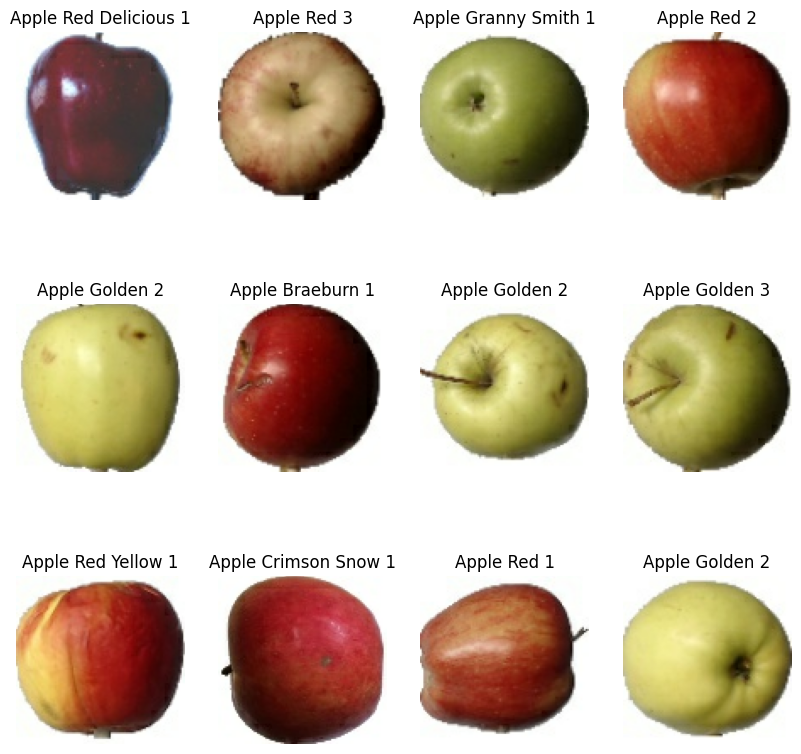

In [5]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
  print(image_batch.shape)
  print(label_batch.numpy())
  for i in range(12):
    ax = plt.subplot(3,4, i+1)
    plt.imshow(image_batch[i].numpy().astype('uint8'))
    plt.title(class_name[label_batch[i]])
    plt.axis('off')

In [6]:
from random import seed
def get_dataset_partition_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1,shuffle=True, shuffle_size=10000):

  assert(train_split+test_split+val_split) ==1
  ds_size = len(ds)

  if shuffle:
    ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [7]:
train_ds, val_ds, test_ds=get_dataset_partition_tf(dataset)

In [8]:
len(train_ds)

160

In [9]:
len(val_ds)

20

In [10]:
len(test_ds)

21

In [13]:
from keras import layers
resize_and_rescale=tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [15]:
# Data Augmentation
data_augmention=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [16]:
input_shape=(BATCH_SIZE, IMAGE_SIZE,IMAGE_SIZE,CHANNEL)
n_classes = 13
model=Sequential([
    resize_and_rescale,
    data_augmention,
    layers.Conv2D(32, kernel_size=(3,3),activation="relu", input_shape = input_shape),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3),activation="relu"),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3),activation="relu"),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3),activation="relu"),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3),activation="relu"),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dense(n_classes, activation="softmax")

])
model.build(input_shape=input_shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 100, 100, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 100, 100, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 98, 98, 32)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 49, 49, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 47, 47, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 23, 23, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 21, 21, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 10, 10, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 8, 8, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 4, 4, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 2, 2, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 1, 1, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 128)              │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 13)               │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,173 (547.55 KB)

 Trainable params: 140,173 (547.55 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [19]:
history=model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCH
)

Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1225s 163ms/step - accuracy: 0.4576 - loss: 1.4614 - val_accuracy: 0.6172 - val_loss: 0.9847
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 40s 154ms/step - accuracy: 0.7612 - loss: 0.6350 - val_accuracy: 0.8547 - val_loss: 0.3954
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 0.8771 - loss: 0.3279 - val_accuracy: 0.9781 - val_loss: 0.0932
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 43s 175ms/step - accuracy: 0.9399 - loss: 0.1585 - val_accuracy: 0.9641 - val_loss: 0.1292
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 42s 170ms/step - accuracy: 0.9201 - loss: 0.2126 - val_accuracy: 0.9797 - val_loss: 0.0663
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 0.9586 - loss: 0.1066 - val_accuracy: 0.9609 - val_loss: 0.0976
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 83s 177ms/step - accuracy: 0.9470 - loss: 0.1589 - val_accuracy: 0.9625 - val_loss: 0.0901
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 42s 172ms/step - accuracy: 0.9782 - loss:

In [20]:
score=model.evaluate(test_ds)

21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.9836 - loss: 0.0437


In [21]:
score

[0.04372578114271164, 0.9836309552192688]

In [22]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Loss')

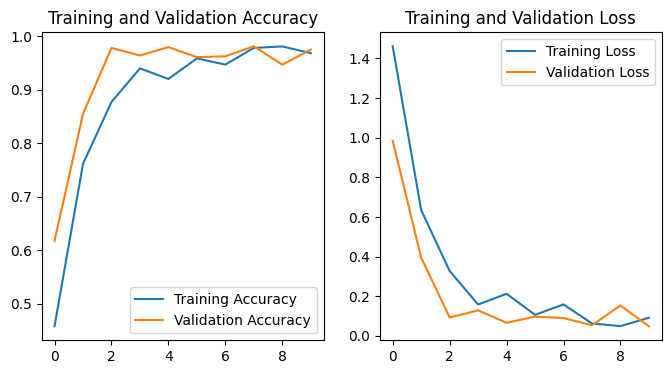

In [25]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(range(EPOCH), acc, label="Training Accuracy")
plt.plot(range(EPOCH), val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(EPOCH), loss, label="Training Loss")
plt.plot(range(EPOCH), val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")

first image to predict
actual label: Apple Crimson Snow 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
Predicted labels Apple Crimson Snow 1


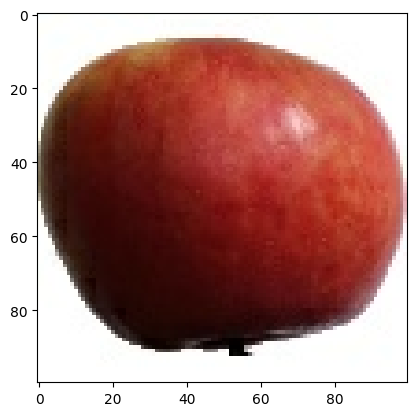

In [26]:
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype("uint8")
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_name[first_label])

    batch_prediction = model.predict(images_batch)
    print("Predicted labels", class_name[np.argmax(batch_prediction[0])])

In [27]:
def predict(model, img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    prediction = model.predict(img_array)

    predicted_class = class_name[np.argmax(prediction[0])]
    confidence = round(100*(np.max(prediction[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


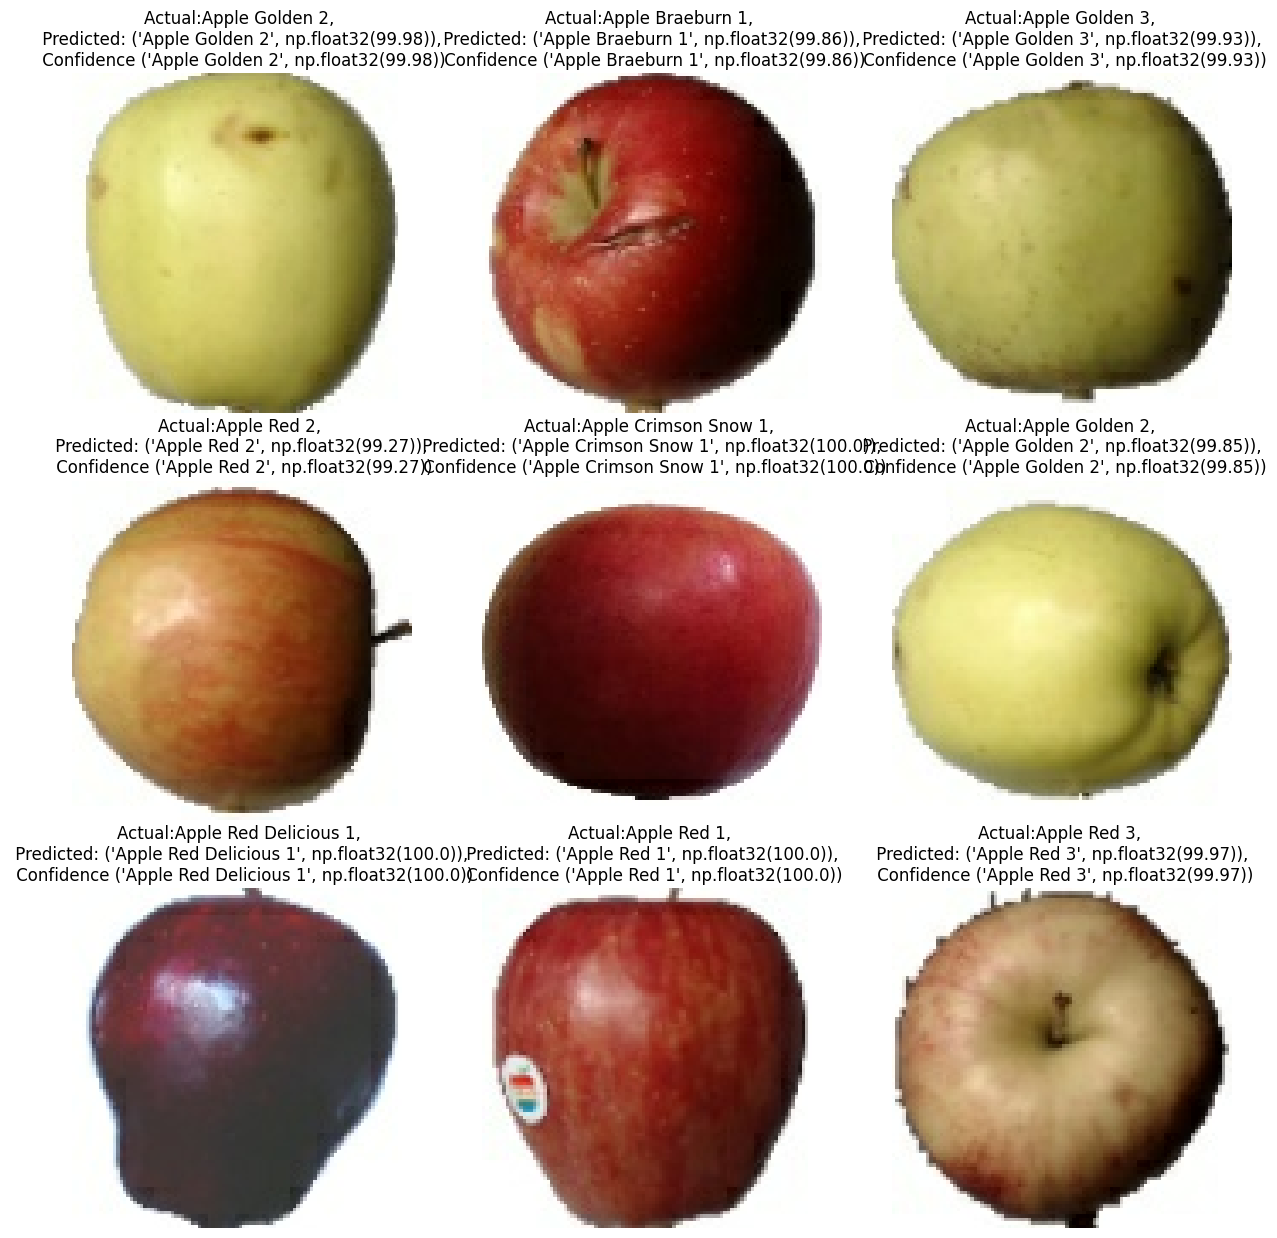

In [28]:
plt.figure(figsize=(15,15))
for images, labels, in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class = confidence = predict(model, images[i].numpy())
        actual_class=class_name[labels[i]]

        plt.title(f"Actual:{actual_class}, \n Predicted: {predicted_class}, \n Confidence {confidence}")

        plt.axis("off")

In [32]:
from tensorflow.keras.models import load_model

In [33]:
model.save("/content/drive/MyDrive/save_model/apple_classification.keras")